## Lunar DEMs

Notebook for loading and visualizing Lunar DEMs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from PIL import Image
Image.MAX_IMAGE_PIXELS = 1000000000 

# autoreload
%load_ext autoreload
%autoreload 2

# TODO: install tqdm
# TODO: make this on a sphere!!

## Loading from file

Files are available to download from https://pgda.gsfc.nasa.gov/products/54

The following code loads DEMs in `.JP2` file format and converts them into numpy array. 

In [2]:
# Read img using PIL Image
# Title : [DEM Name]_[Resolution]_[Latitude Range]_[Longitude Range]
tile_name = 'SLDEM2015_512_60S_30S_180_225'
# tile_name = 'SLDEM2015_512_30S_00S_180_225'
img = Image.open(f'{tile_name}.JP2')  # TODO: change path to file if necesary
img.size

(23040, 15360)

In [37]:
# Convert to numpy array (takes around 1m 30s)
img_np = np.array(img)

In [38]:
# Save as .npy file for future use
np.save(f'{tile_name}.npy', img_np)

Loading directly from `.npy` file (\bf{much faster})

In [3]:
img_np = np.load(f'{tile_name}.npy')

## 2D visualization

In [40]:
img_np.shape

(15360, 23040)

Plot a downsampled version of the DEM

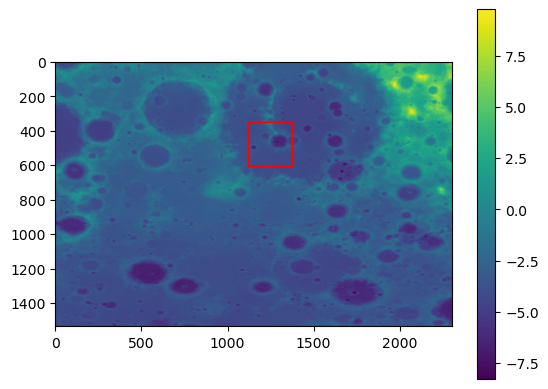

In [4]:
ds_factor = 10
img_np_ds = img_np[::ds_factor, ::ds_factor]
fig = plt.figure()
plt.imshow(img_np_ds*0.0592252938/100 - 17.37400)

import matplotlib.patches as patches
rect = patches.Rectangle((1120, 350), 256, 256, linewidth=1, edgecolor='r', facecolor='none')
# Add the patch to the Axes
ax = plt.gca()
ax.add_patch(rect)

plt.colorbar()
plt.show()

## 3D visualization

Apollo peak ring and Chaffee craters

**Insights**
- Craters are really big, to the point that local path planning can't be really done with the DEMs 

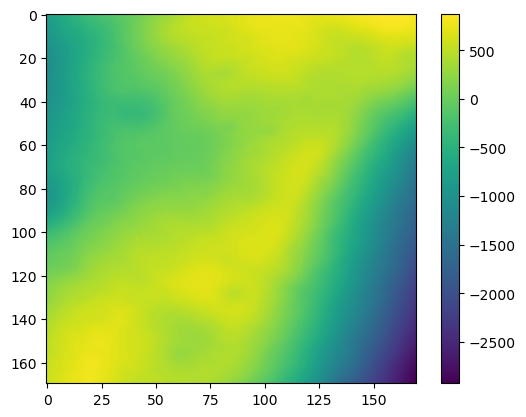

In [14]:
# from the downsampled image
d = int(512/2)
x_loc = img_np_ds.shape[1] - 1050
y_loc = img_np_ds.shape[0] - 950
patch = img_np_ds[y_loc-d:y_loc, x_loc-int(d/2):x_loc+int(d/2)]
Z_down = patch - np.average(patch)

# form the true image
d = int(512/3)
x_loc = img_np.shape[1] - (10*1050)
# y_loc = img_np.shape[0] - (10*950)
# between the Chaffee craters
# y_loc = img_np.shape[0] - (8*1350)

# between the Chaffee craters
y_loc = img_np.shape[0] - (8*1350)-100


patch = img_np[y_loc-d:y_loc, x_loc-int(d/2):x_loc+int(d/2)]
Z = patch - np.average(patch)


# Display the image
plt.imshow(Z)
plt.colorbar()
plt.show()

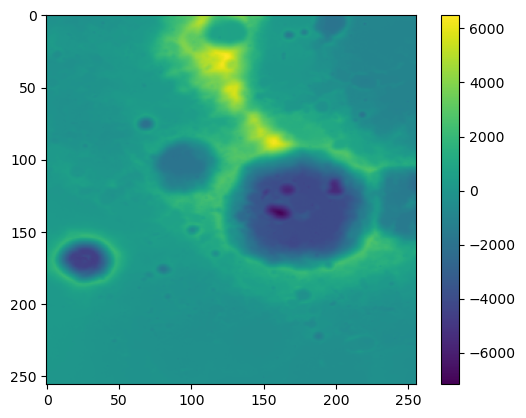

In [15]:
# Display the image
plt.imshow(Z_down)
plt.colorbar()
plt.show()

In [16]:
Z.shape

(170, 170)

In [17]:
170/512

0.33203125

## The conversion is cylindrical, not spherical

https://en.wikipedia.org/wiki/Equirectangular_projection

In [18]:
# Moon's radius in km
R = 1737.400

# 2d to 3d
# x = R*(lambda - lambda_0)
# y = R* tan(phi)


In [19]:
# Moon's radius in meters
R = 1737400
# spherical to cartesian coordinates conversion
def sph2cart(elev, theta, phi):
    r = elev + 1737400/1000
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    return x, y, z

# convert the patch to cartesian coordinates
# 1024 by 1024 pixels = 2 by 2 degrees
lat_list = np.linspace(-30, -32, patch.shape[0])
long_list = np.linspace(180, 182, patch.shape[1])

# get total number of pixels
total_pixels = patch.shape[0] * patch.shape[1]
patch_x = np.zeros((total_pixels))
patch_y = np.zeros((total_pixels))
patch_z = np.zeros((patch.shape[0], patch.shape[1]))

for i, lat in enumerate(lat_list):
    for j, long in enumerate(long_list):

        # get elevation from DEM
        elev = patch[i, j]
        k = np.ravel_multi_index((i, j), patch.shape)

        x, y, z = sph2cart(elev, long, lat)
        patch_x[k] = x
        patch_y[k] = y
        patch_z[i,j] = z


For tile `SLDEM2015_256_60S_0S_120_240_JP2`:
- 256 pixels per degree
- Latitude: 60 deg S - 0 deg S
- Longitude: 120 deg E - 240 deg E

Radius of moon: 1737.4 km

DEM height: 
- Meters: $(60/360) * 2\pi * 1737.4 = 1819.4$ km
- Pixels: 256 * 60 = 15360

DEM width: 
- Meters: $(120/360) * 2\pi * 1737.4 = 3638.8$ km
- Pixels: 256 * 120 = 30720

So we get 118450 meters per pixel. Elevation values are in meters

Note that DEM is not a perfect rectangle in reality, due to curvature.

In [20]:
def dem_meters_per_pixel(resolution, lat_range, long_range, patch_size=1000):
    """
    Calculate the number of meters per pixel in the DEM image.
    """
    # Moon's radius in meters
    R = 1737400
    # DEM Height in meters
    dem_height = ((lat_range[1] - lat_range[0])/360) * 2 * np.pi * R
    dem_height_pixels = resolution * (lat_range[1] - lat_range[0])

    # DEM Width in meters
    dem_width = ((long_range[1] - long_range[0])/360) * 2 * np.pi * R
    dem_width_pixels = resolution * (long_range[1] - long_range[0])

    # #assuming we have a rectangle DEM
    # tot_pixels = dem_height_pixels * dem_width_pixels
    # total_area = dem_height * dem_width
    # meters_per_pixel = total_area / tot_pixels
    meters_per_pixel = patch_size*(dem_height+dem_width) / (dem_height_pixels+ dem_width_pixels)

    return meters_per_pixel

In [21]:
meters_per_pixel_og = int(dem_meters_per_pixel(512, [30, 60], [180, 225]))

In [27]:
#TODO: off by a 1000 (see label file)
meters_per_pixel_og/1000

59.225

In [31]:
# Surface plot to scale
meters_per_pixel = meters_per_pixel_og/1000
xs = np.linspace(0, meters_per_pixel, num=Z.shape[0])
ys = np.linspace(0, meters_per_pixel , num=Z.shape[1])
x, y = np.meshgrid(xs, ys, indexing='xy')

fig = go.Figure(data=[go.Surface(z=Z/1000, x=y, y=x, colorscale='Viridis')])
fig.update_layout(width=1200, height=700, scene_aspectmode='data')
fig.show()

In [13]:
meters_per_pixel

59225